# Initialize the project

In [1]:
import re
import json
import utils

# Loading the dataset

In [2]:
df = utils.load_and_prepare_data("coffee_sales.csv")
utils.print_html(df.sample(n = 5), title =  "Sample of Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-06-24,10:14,card,ANON-0000-0000-0180,3.772,Cappuccino,2,6,2024
2025-02-10,13:31,card,ANON-0000-0000-1200,3.576,Cappuccino,1,2,2025
2024-11-25,13:57,card,ANON-0000-0000-0945,3.576,Hot Chocolate,4,11,2024
2024-10-07,06:11,card,ANON-0000-0000-0724,3.576,Latte,4,10,2024
2024-11-26,17:28,card,ANON-0000-0000-0950,3.086,Americano with Milk,4,11,2024


# The pipeline

In [3]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
  """Generate Python code to make a plot with matplotlib"""
  prompt = f""""
  You are a visualization expert.

  Return your answer *strictly* in this format:

  <execute_python>
  # valid python code here
  </execute_python>

  Do not add explanations, only the tags and the code.

  The code should create a visualization from a DAtaFrame 'df' with these columns:
  - date (datetime64 - already parsed; use df['date'].dt.year, df['date'].dt.month, et.)
  - time (string, HH:MM - do NOT concatenate with the date column)
  - cash_type (string: 'card' or 'cash')
  - price (number)
  - coffee_name (string)
  - quarter (int, 1-4 - already computed, use directly)
  - month (int, 1-12 - already computed, use directly)
  - year (int, e.g. 2024 - already computed, use directly)

  User instruction: {instruction}

  Requirements for the code:
  1. Assume the DataFrame is already loaded as 'df'.
  2. Use matplotlib for plotting.
  3. Add clear title, axis labels, and legend if needed.
  4. Save the figure as '{out_path_v1}' with dpi=300.
  5. Do not call plt.show().
  6. Close all plots with plt.close().
  7. Add all necessary import python statements
  8. CRITICAL: 'date is datetime64 - never use string concatenation on it.
     Filter by year/quarter using the 'year' and 'quarter' integer columns.

  Return ONLY the code wrapped in <execute_python> tags.
  """

  response = utils.get_response(model, prompt)
  return response

# Generate the code

In [4]:
code_v1 = generate_chart_code(
  instruction = "Create a plt comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
  model="gpt-4o-mini",
  out_path_v1 = "chart_v1.png"
)

utils.print_html(code_v1, title = "Generated Code for Chart v1")

# Execute code and create the chart


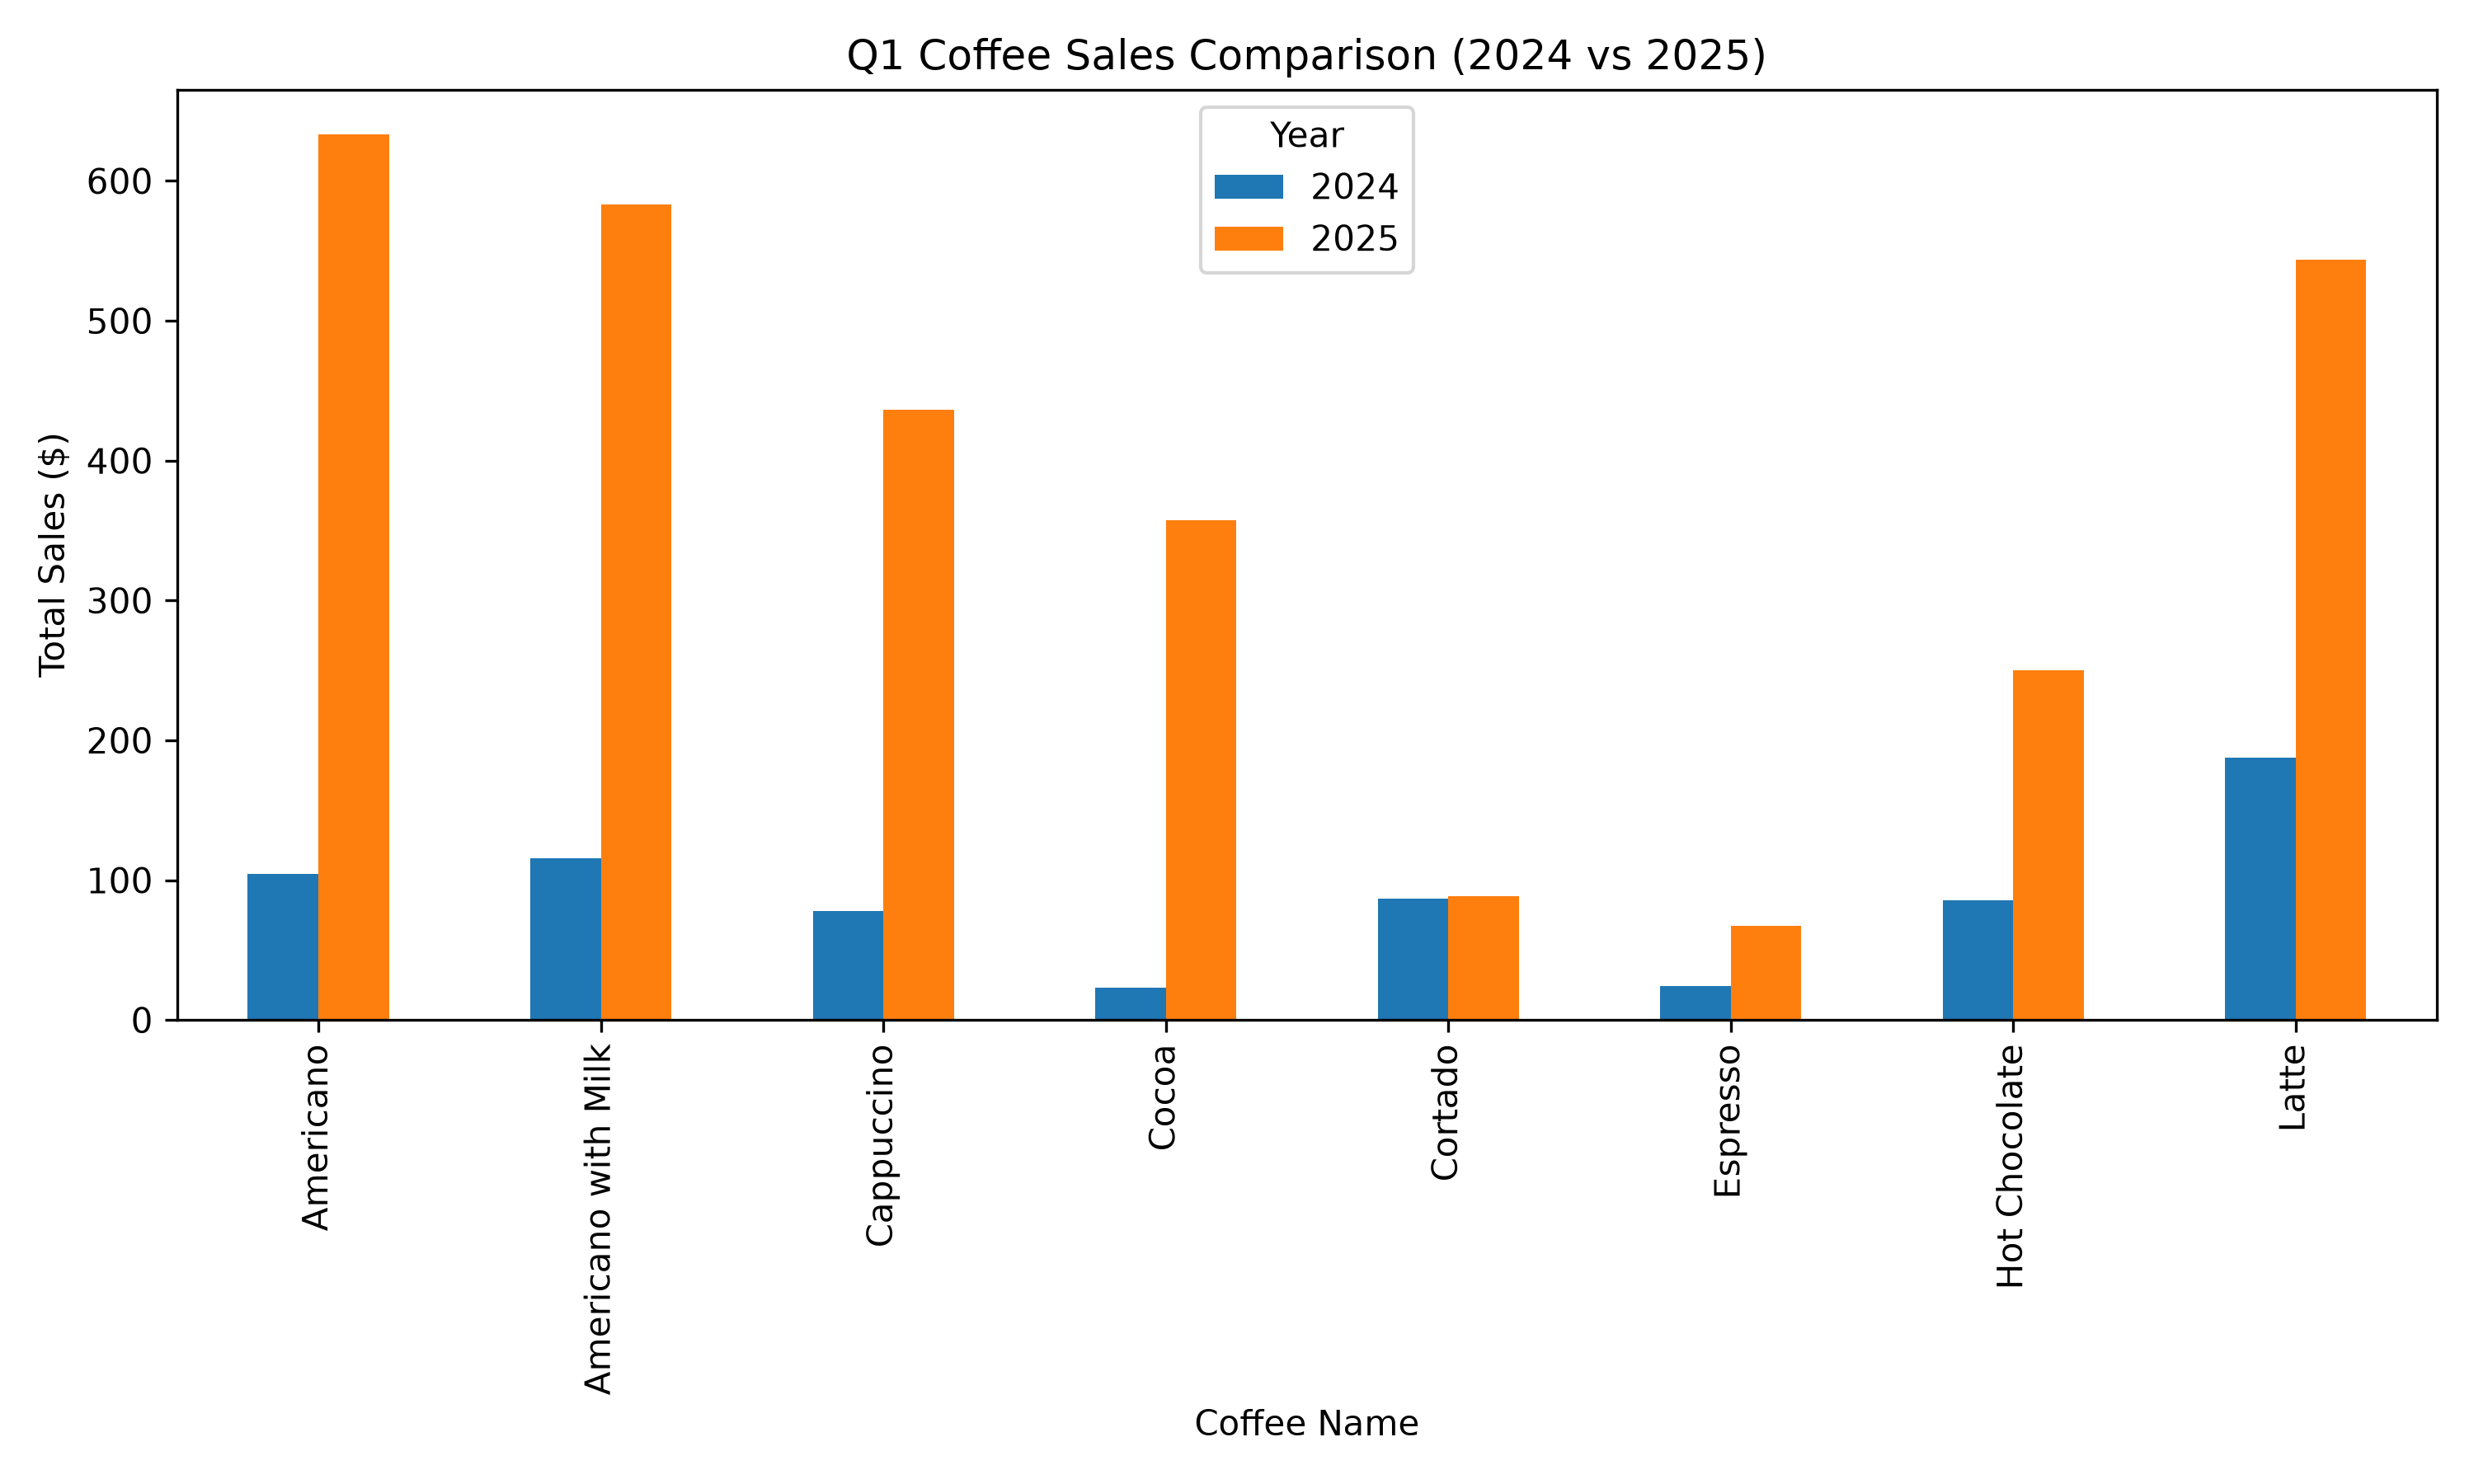

In [5]:
match = re.search(r"<execute_python>(.*?)</execute_python>", code_v1, re.DOTALL)

if match:
  initial_code = match.group(1).strip()
  utils.print_html(initial_code, title = "Initial Code to Execute")
  exec_globals = {"df": df}
  exec(initial_code, exec_globals)
else:
  raise ValueError(f"Could not find <execute_python> tags in model output:\n{code_v1}")

utils.print_html(
  content = "chart_v1.png",
  title = "Generated Chart v1",
  is_image = True
)

# Reflect on the outcome

In [6]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,
) -> tuple[str, str]:
    """
    Critique the chart IMAGE and the original code against the instruction,
    then return refined matplotlib code.
    Returns (feedback, refined_code_with_tags).
    Supports OpenAI and Anthropic (Claude).
    """
    media_type, b64 = utils.encode_image_b64(chart_path)


    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.

    IMPORTANT: The 'date' column is already a pandas datetime64 type.
    - Do NOT concatenate 'date' with 'time' using string operations.
    - To filter by year/quarter, use: df[df['year'] == 2024] or df['date'].dt.year == 2024
    - The 'quarter' and 'year' columns already exist as integers; use them directly.

    Schema (columns available in df):
    - date   (datetime64 — already parsed; use df['date'].dt.year, etc.)
    - time   (string, HH:MM — do NOT concatenate with date)
    - cash_type (string: 'card' or 'cash')
    - card   (string)
    - price  (float)
    - coffee_name (string)
    - quarter (int, 1–4)
    - month  (int, 1–12)
    - year   (int)

    CRITICAL TYPE RULE: 'date' is already datetime64.
    - NEVER do: df['date'] + ' ' + df['time']  ← this will crash
    - ALWAYS filter by year/quarter using the integer columns: df[df['year'] == 2024]

    Instruction:
    {instruction}
    """


    # In case the name is "Claude" or "Anthropic", use the safe helper
    lower = model_name.lower()
    if "claude" in lower or "anthropic" in lower:
        # ✅ Use the safe helper that joins all text blocks and adds a system prompt
        content = utils.image_anthropic_call(model_name, prompt, media_type, b64)
    else:
        content = utils.image_openai_call(model_name, prompt, media_type, b64)

    # --- Parse ONLY the first JSON line (feedback) ---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line)
    except Exception as e:
        # Fallback: try to capture the first {...} in all the content
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}", "refined_code": ""}
        else:
            obj = {"feedback": f"Failed to find JSON: {e}", "refined_code": ""}

    # --- Extract refined code from <execute_python>...</execute_python> ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code



# Generate and execute reflection code

In [7]:
feedback, code_v2 = reflect_on_image_and_regenerate(
  chart_path = "chart_v1.png",
  instruction = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
  model_name = "o4-mini",
  out_path_v2 = "chart_v2.png",
  code_v1 = code_v1
)

utils.print_html(feedback, title = "Feedback on Chart v1")
utils.print_html(code_v2, title = "Refined Code for Chart v2")


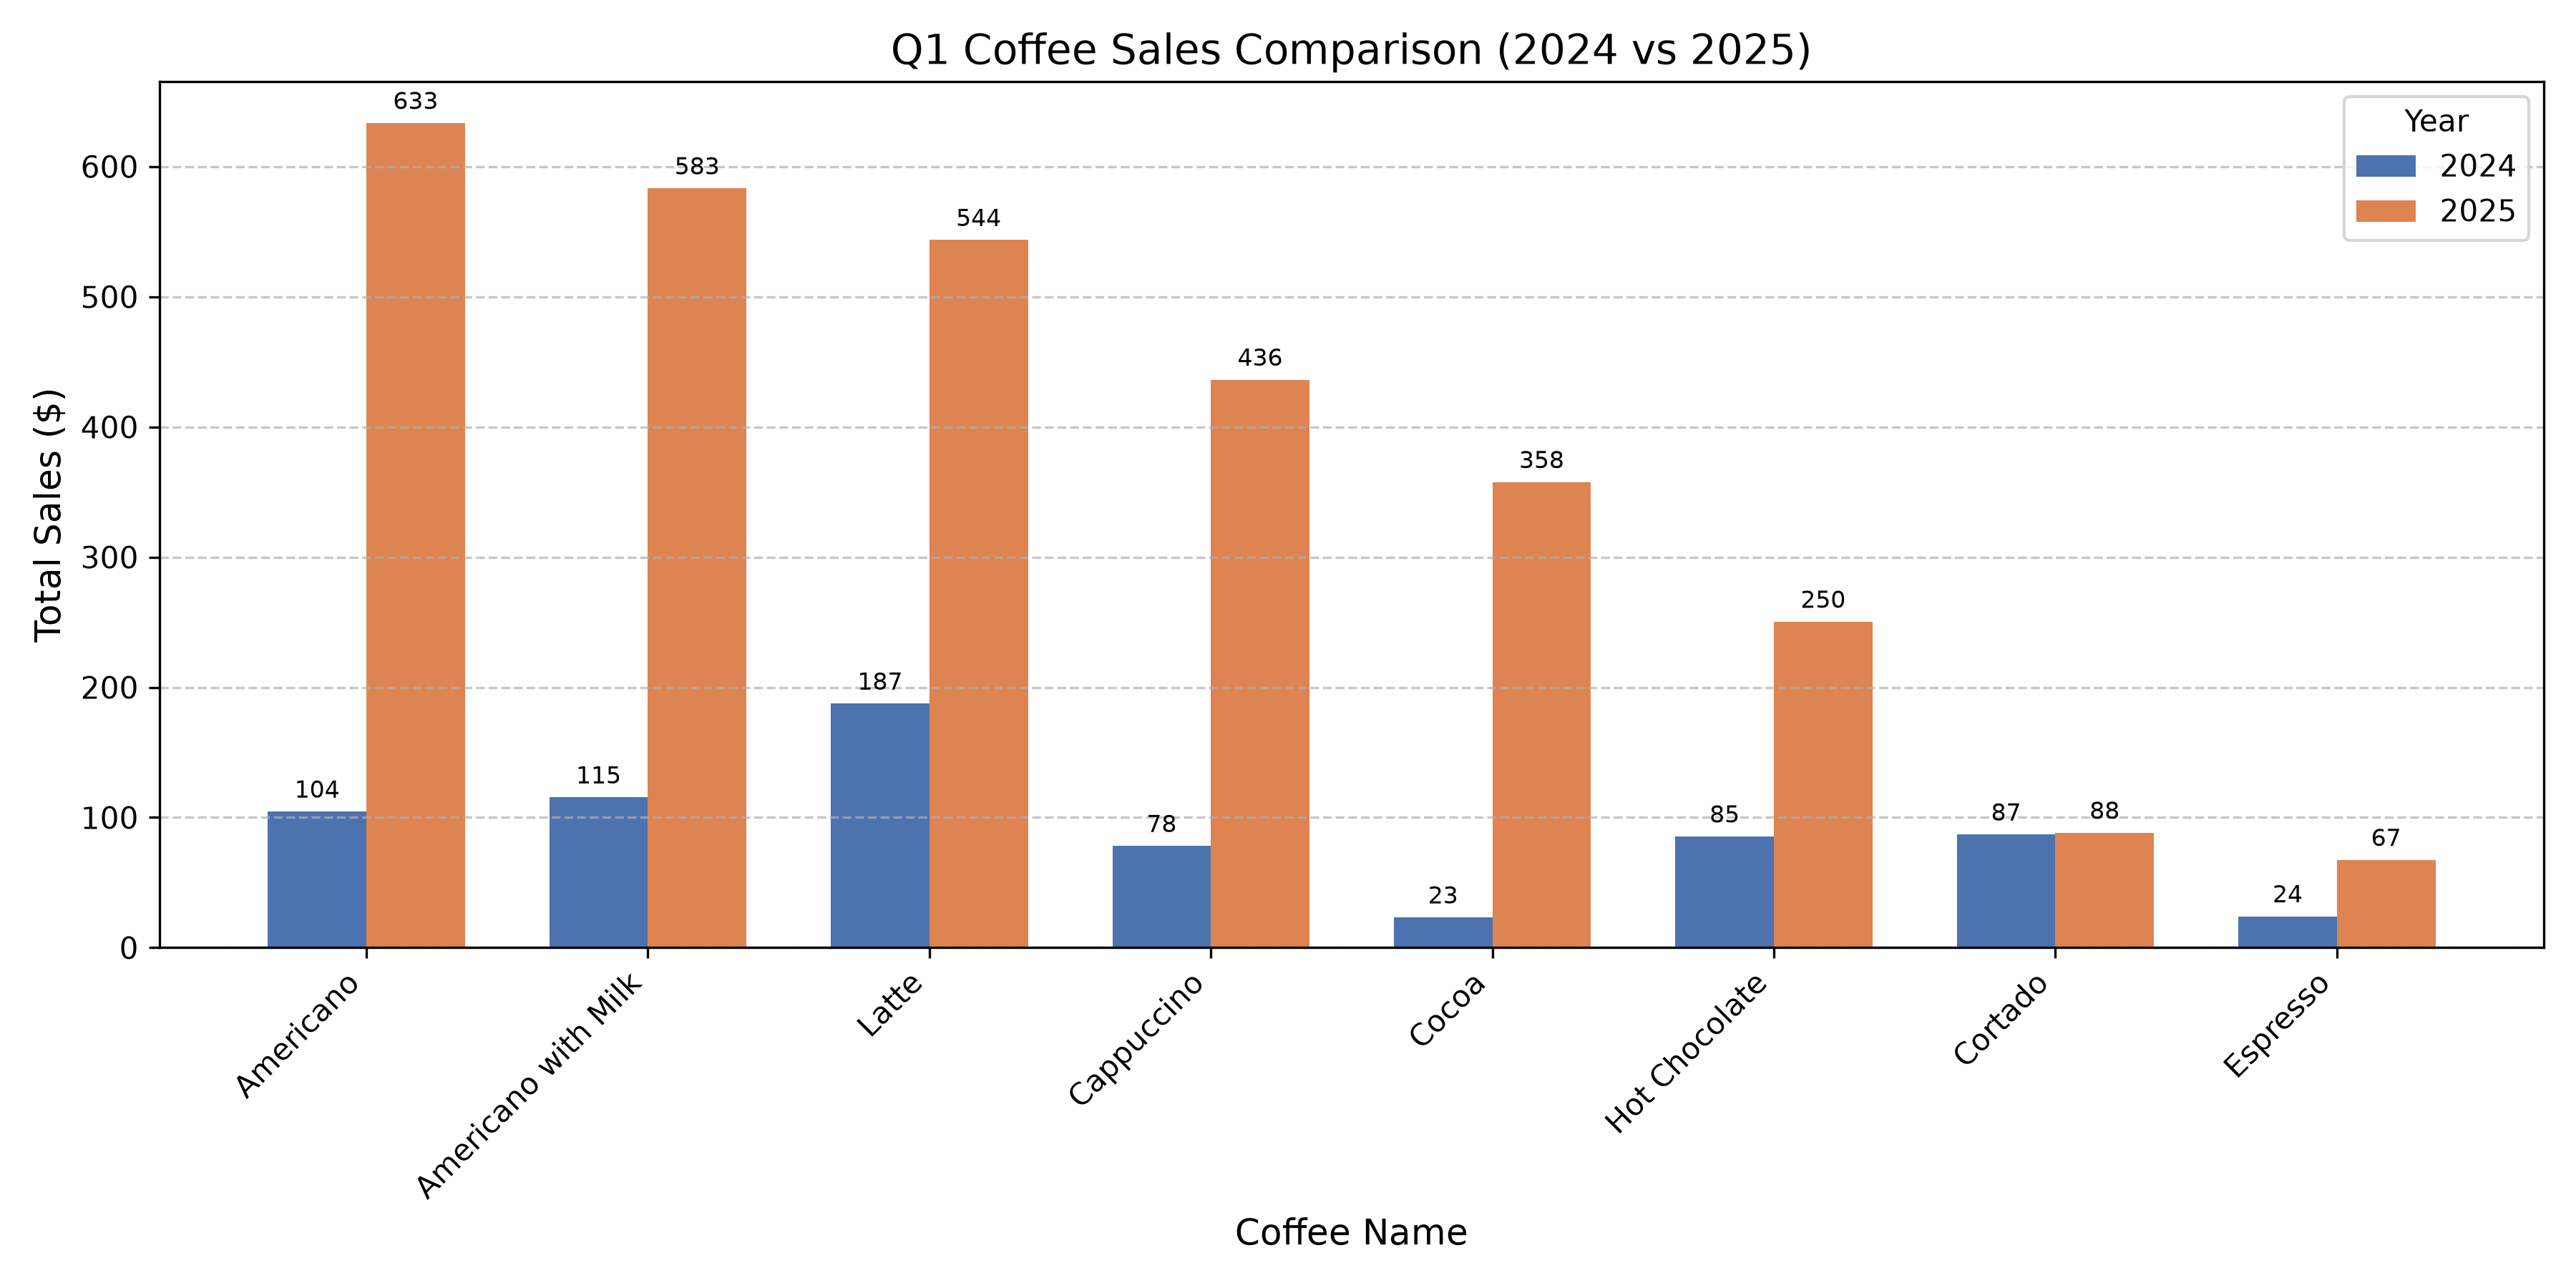

In [8]:
# Get the code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# If code run successfully, the file chart_v2.png should have been generated
utils.print_html(
    content="chart_v2.png",
    title="Regenerated Chart (V2)",
    is_image=True
)

# Final: The Workflow

In [9]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,
    image_basename: str = "chart",
):
  """
  End-to-end pipeline:
  1) Load dataset
  2) Generate V1 code
  3) Execute V1 -> produce chart_v1.png
  4) Reflect on V1 (image + original code) -> feedback + refined code
  5) Execute V2 -> product chart_v2.png

  Returns a dict with all artifacts (codes, feedback, image paths).
  """

  # 1) Load dataset
  df = utils.load_and_prepare_data(dataset_path)
  utils.print_html(df.sample(n=5), title="Sample of Coffee Sales Data")

  out_v1 = f"{image_basename}_v1.png"
  out_v2 = f"{image_basename}_v2.png"

  # 2) Generate V1 code
  utils.print_html("Step 1: Generating V1 code...", title="Workflow Step 1")
  code_v1 = generate_chart_code(
      instruction=user_instructions,
      model=generation_model,
      out_path_v1=out_v1
  )
  utils.print_html(code_v1, title="Generated Code for Chart V1")

  # 3) Execute V1 code
  utils.print_html("Step 2: Executing V1 code...", title="Workflow Step 2")
  match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
  if match:
      initial_code = match.group(1).strip()
      exec_globals = {"df": df}
      exec(initial_code, exec_globals)
  utils.print_html(
      content=out_v1,
      title="Generated Chart V1",
      is_image=True
  )

  # 4) Reflect on V1
  utils.print_html("Step 3: Reflecting on V1 chart...", title="Workflow Step 3")
  feedback, code_v2 = reflect_on_image_and_regenerate(
      chart_path=out_v1,
      instruction=user_instructions,
      model_name=reflection_model,
      out_path_v2=out_v2,
      code_v1=code_v1
  )
  utils.print_html(feedback, title="Feedback on Chart V1")
  utils.print_html(code_v2, title="Refined Code for Chart V2")

  # 5) Execute V2 code
  utils.print_html("Step 4: Executing V2 code...", title="Workflow Step 4")
  match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
  if match:
      reflected_code = match.group(1).strip()
      exec_globals = {"df": df}
      exec(reflected_code, exec_globals)
  utils.print_html(
      content=out_v2,
      title="Regenerated Chart V2",
      is_image=True
  )

  return {
      "code_v1": code_v1,
      "chart_v1": out_v1,
      "feedback": feedback,
      "code_v2": code_v2,
      "chart_v2": out_v2
  }


# Running the workflow

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-09-20,14:18,card,ANON-0000-0000-0642,3.282,Latte,3,9,2024
2024-11-18,14:32,card,ANON-0000-0000-0906,3.576,Latte,4,11,2024
2025-02-20,15:05,card,ANON-0000-0000-1163,2.596,Americano,1,2,2025
2024-11-23,09:53,card,ANON-0000-0000-0683,3.576,Latte,4,11,2024
2025-01-31,12:23,card,ANON-0000-0000-1145,3.576,Cocoa,1,1,2025



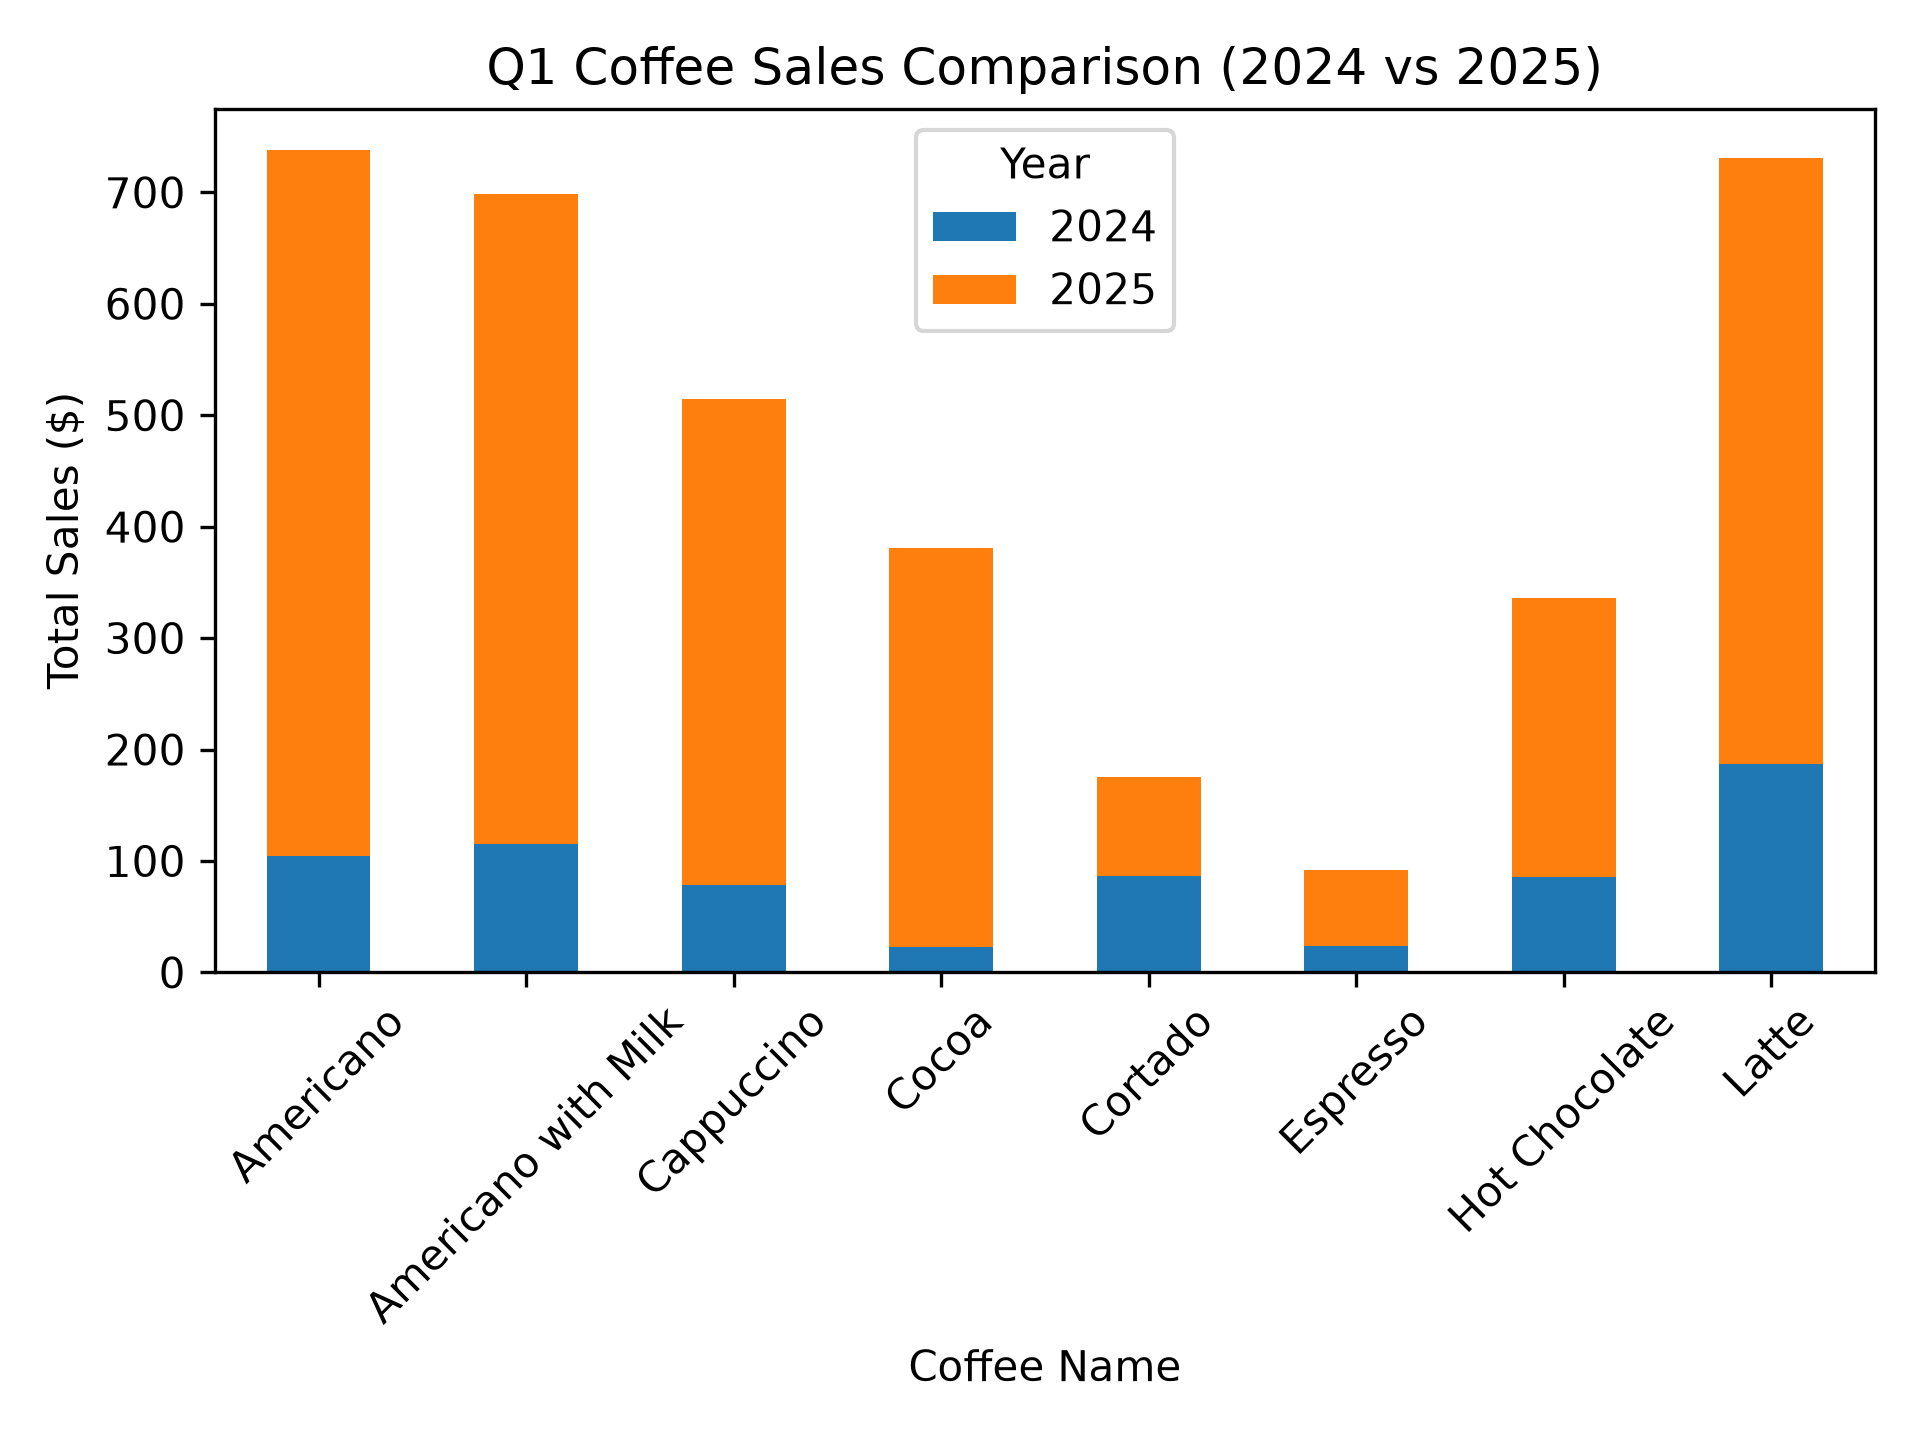


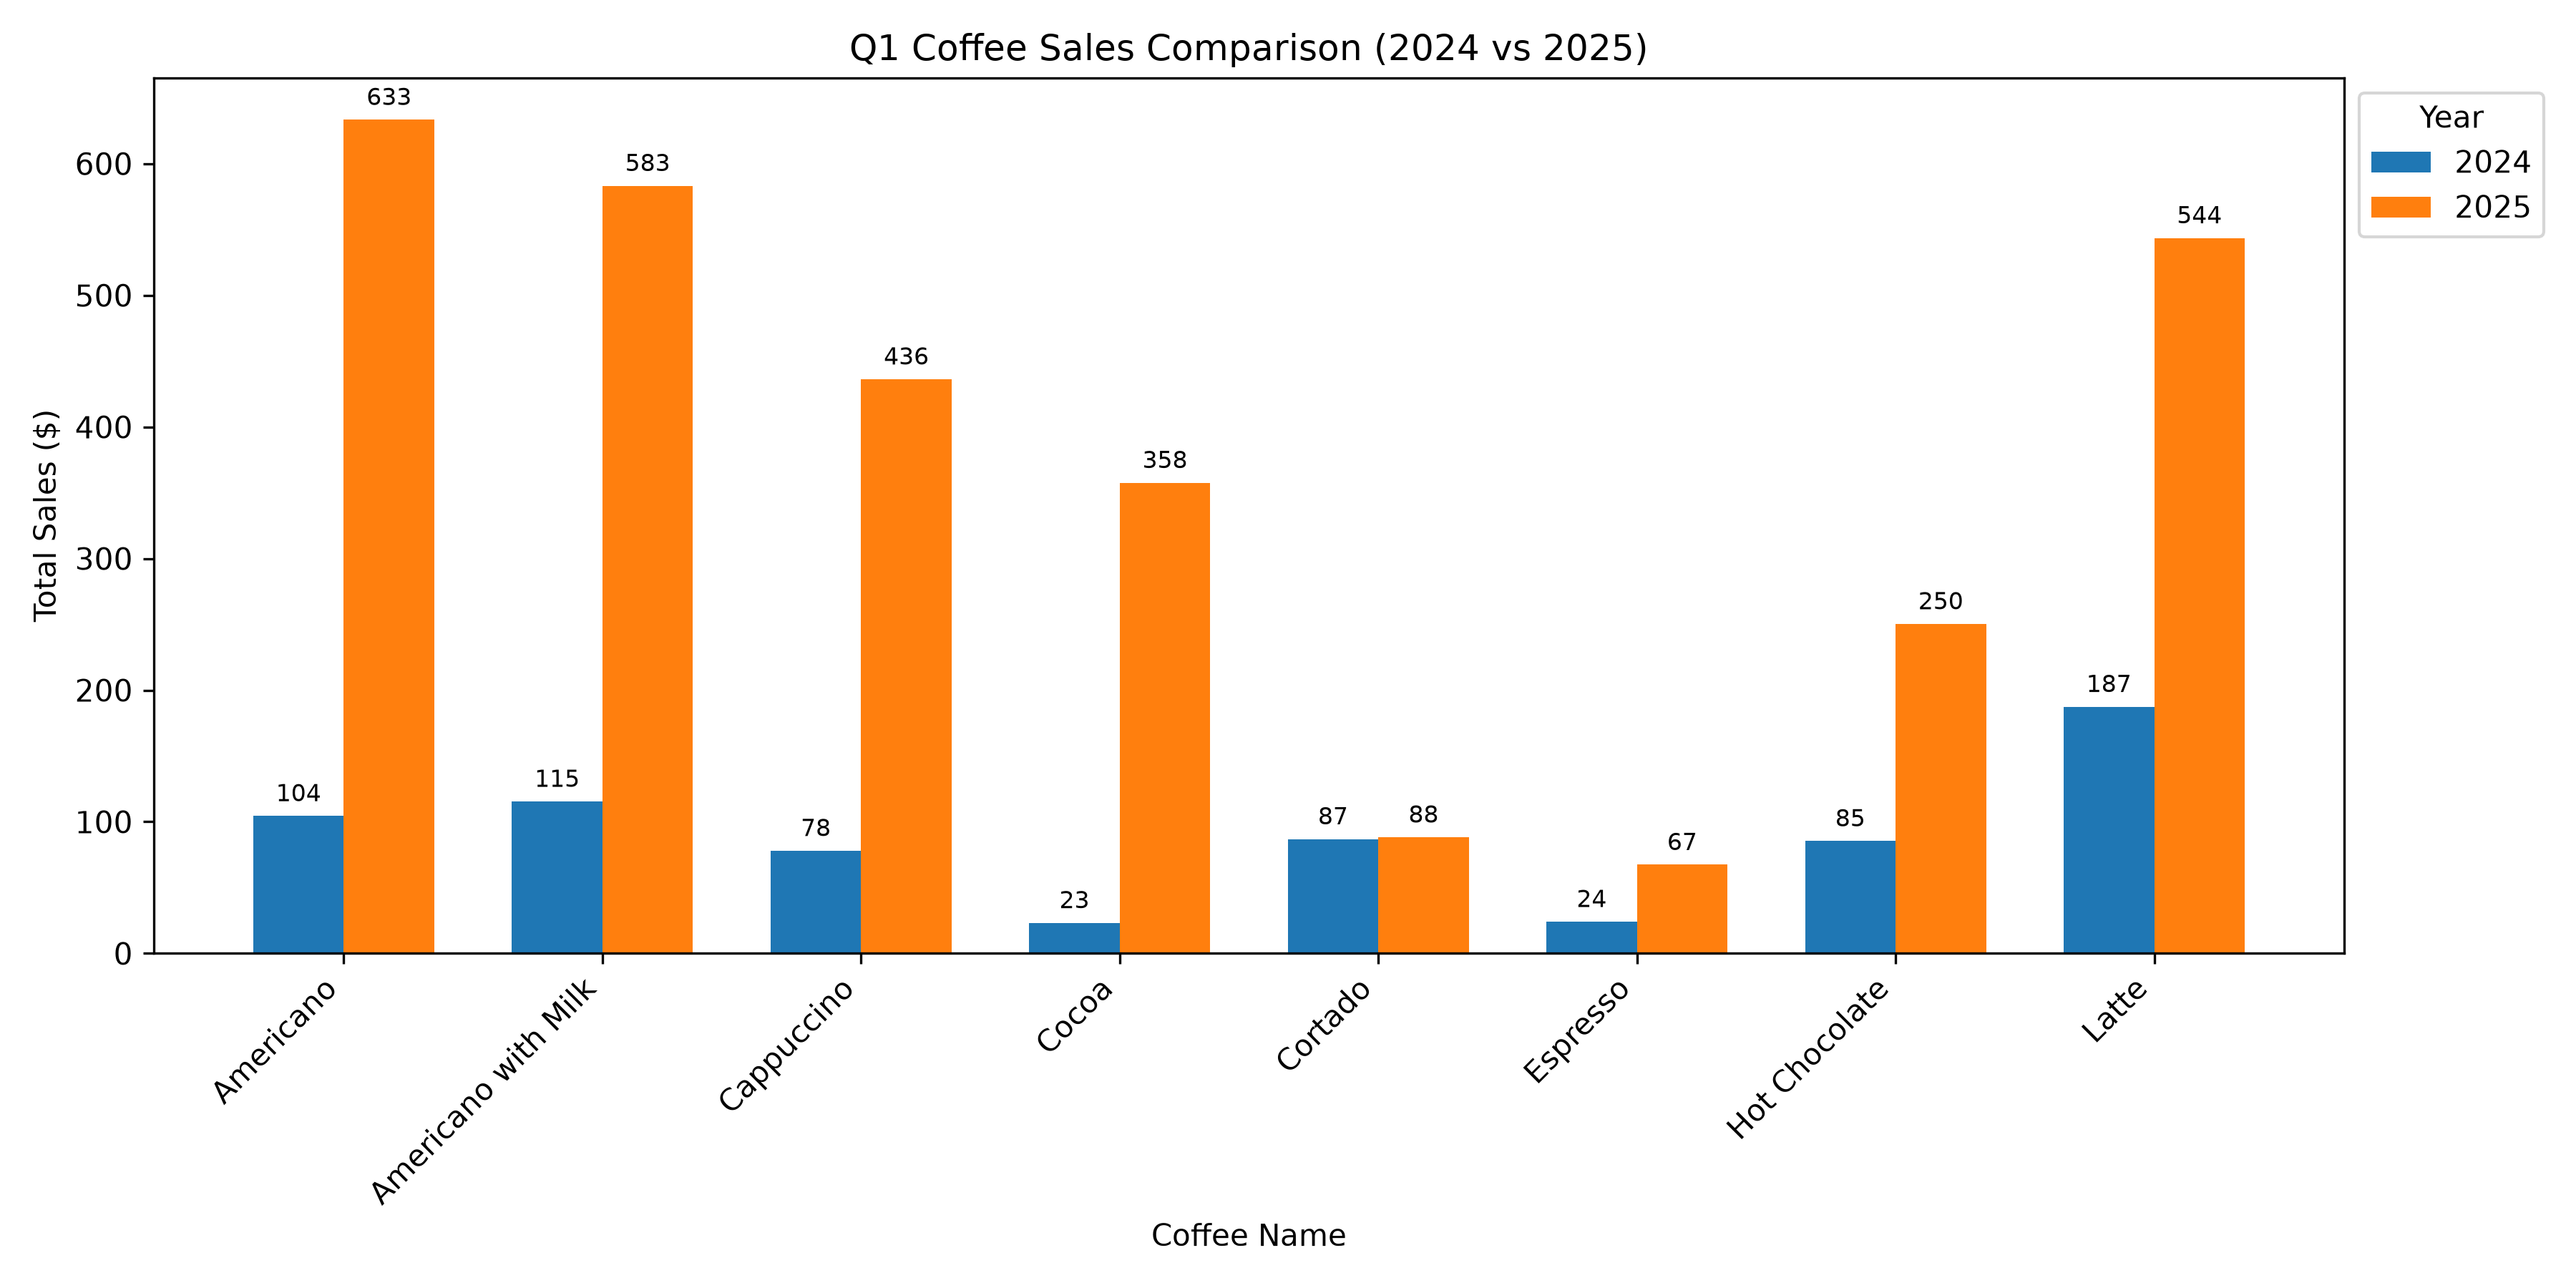

<Figure size 1000x600 with 0 Axes>

In [10]:
user_instructions = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."
generation_model = "gpt-4o-mini"
reflection_model = "o4-mini"
image_basename = "drink_sales"

_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)